# The Articulation Story — §4.1–4.3 data notebook
*2026-08-10 — one place to explore every result behind the articulation sections.*

**Data pack**: `outputs/articulation_story_20260810/` (all files local; nothing here touches the cluster).
- `zxa_panels/` — channel-arm score matrices per (task, receiver): `mbar_zxa_{task}_{exec}.npz`, GLM rows in `mbar_zxaglm_*`
- `gen_panels/` — generative-readout panels (qwen3 think/nothink rungs, R1/phi4 pairs, gpt-oss-120b)
- `flips/` — flip-selected exemplar instruments (v2/v3 selections, ladder npz, frontier + mm controls, de-censor run)
- `analyses/` — harvested summary artifacts (ledgers, censuses, curves) — these carry the *canonical* numbers
- `freezes/` — the frozen slates/rubrics that define every arm

**Reading rules (from the campaign's advisor-audited phrasing law):**
1. Notebook recomputations below use **all 300 probes** for exploration; the note-canonical numbers use the stable-hash holdout — expect small differences, and quote only the note/ledger numbers.
2. The two exemplar ledgers (§4.2b) are **different quantities** and are never merged: 70B-receiver *fun−def* wins vs cross-receiver *fun−mm* content.
3. News task appears only panel-internally (probe-universe landmine); it is excluded from every panel↔fresh join here.
4. Placebo-matched cells (mm ≈ true) are anchoring, never content wins.

In [1]:
import glob, json, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
D = "../outputs/articulation_story_20260810"
TASKS = ["humor", "creative_writing", "math", "peer_review"]
LADDER = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
          "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
def lp(p):
    if not os.path.exists(p): return {}
    z = np.load(p, allow_pickle=True)
    return {str(n): z["m_bar"][i] for i, n in enumerate([str(x) for x in z["names"]])}
def balanced(pred, lab):
    ok = (lab >= 0) & np.isfinite(pred)
    if ok.sum() < 30: return None
    p = (pred[ok] > .5).astype(int); l = lab[ok]
    accs = [float(np.mean(p[l == c] == c)) for c in (0, 1) if (l == c).sum() >= 5]
    return float(np.mean(accs)) if len(accs) == 2 else None
# 4-voter frontier reference per (task, base): llama70b/qwen25-72b/glm-47/glm-52 dossier majority
PAN = {t: {ex: lp(f"{D}/zxa_panels/mbar_zxa_{t}_{ex}.npz") for ex in LADDER} for t in TASKS}
GLM = {t: {g: lp(f"{D}/zxa_panels/mbar_zxaglm_{t}_{g}.npz") for g in ("glm-47","glm-52")} for t in TASKS}
def ref_for(task, base):
    votes = []
    for src in (PAN[task].get("llama70b", {}), PAN[task].get("qwen25-72b", {}),
                GLM[task].get("glm-47", {}), GLM[task].get("glm-52", {})):
        r = src.get(base + "||dossier")
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.nanmean(np.stack(votes), 0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
slate = json.load(open(f"{D}/freezes/zxa_slate_v1.json"))
CLASS = {(m["task"], m["name"]): m["class"] for m in slate}
print("panels loaded:", sum(len(v) for v in PAN.values()), "receiver-task cells")

panels loaded: 40 receiver-task cells


## 4.1 Code metrics — the code-checkable end of the construct spectrum

**Claim (certified):** constructs whose truth is computable by code (the PLANTED sanity family: digit-presence, question-mark, quote, length rules) are articulable to essentially every listener through nearly every channel — they sit at the ceiling of every recovery curve. They are the existence proof that the articulation pipeline works; the interesting science is everything below them.

**Which metrics win here:** the planted/mechanical constructs themselves, plus real constructs that behave like them (high recovery from the *name alone* — see the name-sufficient list in §4.2). From the unit-type audit (ledger HB172): the Ω unit pools that power Table 1 are 292 CRAFT / 68 MECH / **0 TASTE** — code-adjacent, checkable units dominate what optimizers mine.

*(The MECH/CRAFT/TASTE unit-label file wasn't in the pack at build time — pointer: ledger HB172, `omega_unit_labels_checkability.json`.)*

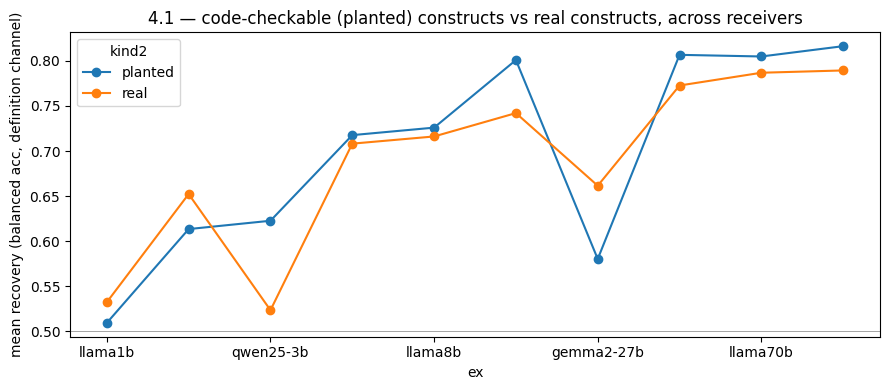

kind2,planted,real
ex,,
llama1b,0.509,0.532
llama3b,0.613,0.652
qwen25-3b,0.623,0.523
qwen25-7b,0.718,0.708
llama8b,0.726,0.716
qwen25-14b,0.801,0.742
gemma2-27b,0.580,0.662
qwen25-32b,0.807,0.773
llama70b,0.805,0.787


In [2]:
# PLANTED vs real-construct recovery, per receiver (definition channel; task = humor)
rows = []
for t in TASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {})})
    for ex in LADDER:
        pan = PAN[t].get(ex, {})
        for b in bases:
            r = pan.get(b + "||definition")
            if r is None: continue
            lab = ref_for(t, b)
            if lab is None: continue
            y = balanced(np.asarray(r, float), lab)
            if y is None: continue
            cls = CLASS.get((t, b), "PLANTED" if b.startswith("PLANTED") else "?")
            rows.append({"task": t, "ex": ex, "base": b, "recovery": y,
                         "kind": "PLANTED (code-checkable)" if b.startswith("PLANTED") else cls})
df41 = pd.DataFrame(rows)
piv = (df41.assign(kind2=np.where(df41["kind"].str.startswith("PLANTED"), "planted", "real"))
       .groupby(["ex", "kind2"])['recovery'].mean().unstack().reindex(LADDER))
ax = piv.plot(marker="o", figsize=(9, 4))
ax.set_ylabel("mean recovery (balanced acc, definition channel)")
ax.set_title("4.1 — code-checkable (planted) constructs vs real constructs, across receivers")
ax.axhline(.5, color="gray", lw=.5); plt.tight_layout(); plt.show()
piv.round(3)

## 4.2 Prompt parts (articulation channels) — which parts matter, which metrics win in each

Channels, in increasing articulation richness: **name → definition (+padded control) → explanation → dossier** (+ `dossier_mismatched` placebo).

**Certified findings:**
- Recovery rises with both channel richness and receiver capability; the placebo (`dossier_mismatched`) stays at floor — the gains are content, not length.
- MI census (canonical: `analyses/mi_upper_census_v1.json`): **name** is high-entropy but least efficient (talkative, uninformative, medEff .06–.15); **dossier** spends output entropy and converts it — most degenerate (22–53%) but most efficient when it varies (medEff .24–.55).
- Degeneracy is capability-graded (llama 49%→14%, 1B→70B), with two mirror anomalies: qwen25-3b (89% constant output — its cells are floor artifacts) and gemma2-27b (variance *without* information — the cross-family dialect signature).

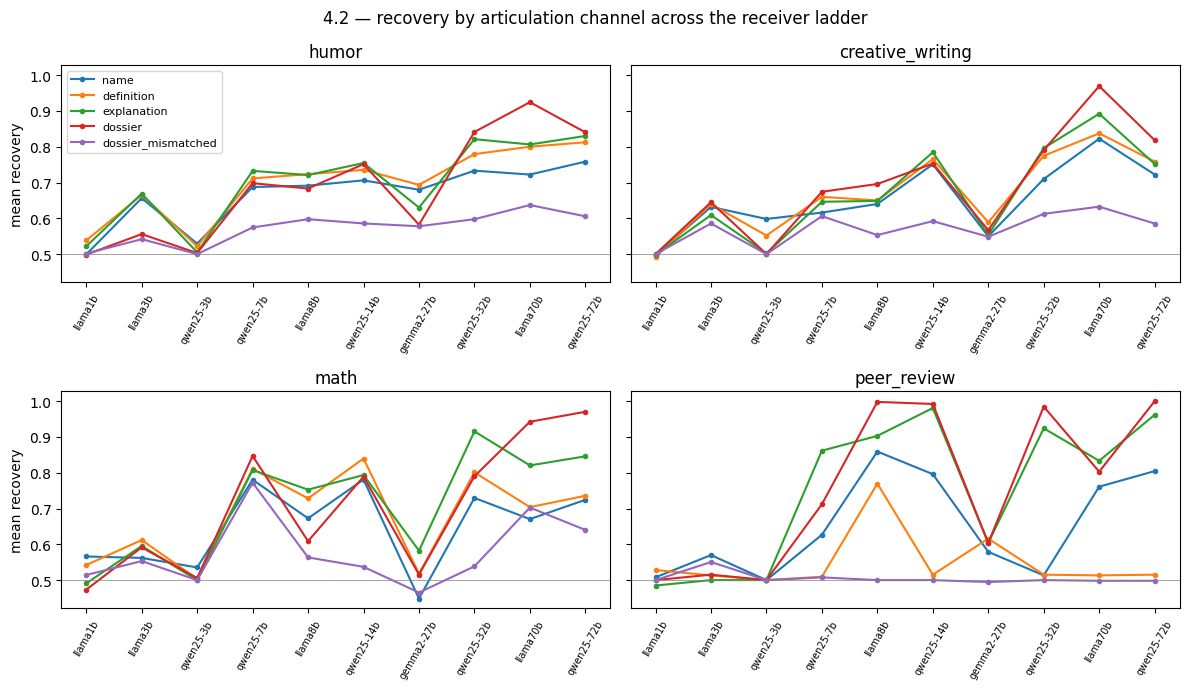

In [3]:
# channel curves over the receiver ladder (mean recovery per channel), one panel per task
ARMS = ["name", "definition", "explanation", "dossier", "dossier_mismatched"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
for ax, t in zip(axes.flat, TASKS):
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for arm in ARMS:
        ys = []
        for ex in LADDER:
            vals = []
            for b in bases:
                r = PAN[t].get(ex, {}).get(f"{b}||{arm}")
                lab = ref_for(t, b)
                if r is None or lab is None: continue
                y = balanced(np.asarray(r, float), lab)
                if y is not None: vals.append(y)
            ys.append(np.mean(vals) if vals else np.nan)
        ax.plot(range(len(LADDER)), ys, marker=".", label=arm)
    ax.set_title(t); ax.set_xticks(range(len(LADDER)))
    ax.set_xticklabels(LADDER, rotation=60, fontsize=7); ax.axhline(.5, color="gray", lw=.5)
axes[0][0].set_ylabel("mean recovery"); axes[1][0].set_ylabel("mean recovery")
axes[0][0].legend(fontsize=8)
fig.suptitle("4.2 — recovery by articulation channel across the receiver ladder")
plt.tight_layout(); plt.show()

In [4]:
# which metrics win per channel: per-base best channel at the top same-family rung (llama70b)
win_rows = []
for t in TASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for b in bases:
        lab = ref_for(t, b)
        if lab is None: continue
        ys = {}
        for arm in ["name", "definition", "explanation", "dossier"]:
            r = PAN[t]["llama70b"].get(f"{b}||{arm}")
            if r is not None:
                y = balanced(np.asarray(r, float), lab)
                if y is not None: ys[arm] = y
        if len(ys) >= 3:
            best = max(ys, key=ys.get)
            win_rows.append({"task": t, "base": b, **{a: round(v, 3) for a, v in ys.items()},
                             "best_channel": best,
                             "name_sufficient": ys.get("name", 0) >= ys.get("dossier", 1) - .02})
dfw = pd.DataFrame(win_rows)
print("best-channel counts (receiver = llama70b):")
print(dfw.groupby(["task", "best_channel"]).size().unstack(fill_value=0))
print()
print("NAME-SUFFICIENT constructs (name within .02 of dossier — 'the word is enough'):")
dfw[dfw.name_sufficient].sort_values("name", ascending=False).head(15)[["task","base","name","dossier"]]

best-channel counts (receiver = llama70b):
best_channel      definition  dossier  explanation
task                                              
creative_writing           0        4            0
humor                      1       22            1
math                       0        3            0
peer_review                0        0            1

NAME-SUFFICIENT constructs (name within .02 of dossier — 'the word is enough'):


,task,base,name,dossier
20,humor,Shared knowledge and reference accessibility,0.82,0.838


## 4.2b Prompt examples — the shown channel, and which metrics win

**Two ledgers, two quantities (advisor rule: never merge):**

**(i) Beating the definition at the receivers that selected them** (flip-v2 contested slate, *fun−def* on holdout, label-sensitivity certified by null-selection control): winners are **gestalt / surprise-timing mechanics** — Cringe-calibration +.148, Surprise-misdirection +.143, Concrete-imagery +.141, Incongruity-mechanics +.140, One-liners +.102 (16 distinct metrics ≥+.05).

**(ii) Carrying construct-specific content across receivers** (v3sets bank, *fun−mm* vs donor-swap placebo, 203 triples × 2 receivers): content components correlate across receivers **r≈.20 (p≈.005)**; the both-receiver 'winner set' is at chance (perm p=.44) and is not quotable, but **Taste-and-timing on traumatic/charged subjects is individually ~5σ at both receivers** — and the **norm-boundary category** (blind-judge assignment over all 203 names) carries significantly more content than mechanics/other (p=.006 qwen / .0095 combined, LOO-robust). Content ≠ winning: these constructs mostly still lose to their (ceiling-strong) definitions.

**Frontier fate of examples** (gpt-oss-120b headline receiver, GLM-5.2 corroborating; math corroboration small-sample): demonstrations read fine (content gates +.20–.30\*) and still lose to definitions where content is checkable — *the gate opens; the gap never closes*. Every apparent exemplar win at frontier is placebo-matched (anchoring: definitions read as strict checklists collapse gpt-oss toward NO; *any* exemplars — even another construct's — re-calibrate it, +.06\*; at the well-calibrated qwen25-72b the same appendix *hurts* −.13\*).

In [5]:
# (i) 70B-receiver ledger: fun-def wins on the contested slate
led70 = []
for s in ("llama70b", "qwen25-72b"):
    d = json.load(open(f"{D}/flips/flip_functional_v2_{s}.json"))["results"]
    for task, dd in d.items():
        if task == "news_homepages": continue
        for base, rec in dd.items():
            for obj, po in rec.get("objectives", {}).items():
                if obj == "null": continue
                h = po.get("holdout", {})
                if h.get("functional") is not None and h.get("definition") is not None:
                    led70.append({"task": task, "base": base, "receiver": s, "objective": obj,
                                  "definition": h["definition"], "functional": h["functional"],
                                  "delta": round(h["functional"] - h["definition"], 3)})
df70 = pd.DataFrame(led70)
print("flip-v2 ledger — top fun-def wins at the selecting receivers:")
df70.sort_values("delta", ascending=False).head(12)

flip-v2 ledger — top fun-def wins at the selecting receivers:


,task,base,receiver,objective,definition,functional,delta
3,humor,"Compressed, quotable phrasing",llama70b,frontier,0.5511,0.8114,0.260
34,humor,"Surprise, misdirection, and dual‑read clarity",llama70b,frontier,0.6706,0.9059,0.235
90,humor,"Delivery, timing, and commitment",qwen25-72b,encoder,0.7361,0.9618,0.226
42,humor,"Surprise, incongruity, and misdirection mechanics",llama70b,frontier,0.6791,0.9002,0.221
35,humor,"Surprise, misdirection, and dual‑read clarity",llama70b,encoder,0.6261,0.8391,0.213
51,creative_writing,Economy and Precision of Prose,llama70b,encoder,0.5718,0.7719,0.200
36,humor,Observational/everyday‑life humor,llama70b,frontier,0.6808,0.8808,0.200
4,humor,"Compressed, quotable phrasing",llama70b,encoder,0.5336,0.7318,0.198
82,humor,Shared knowledge and reference accessibility,qwen25-72b,frontier,0.5728,0.7529,0.180
20,humor,Concrete imagery and vivid specificity,llama70b,frontier,0.7491,0.9239,0.175


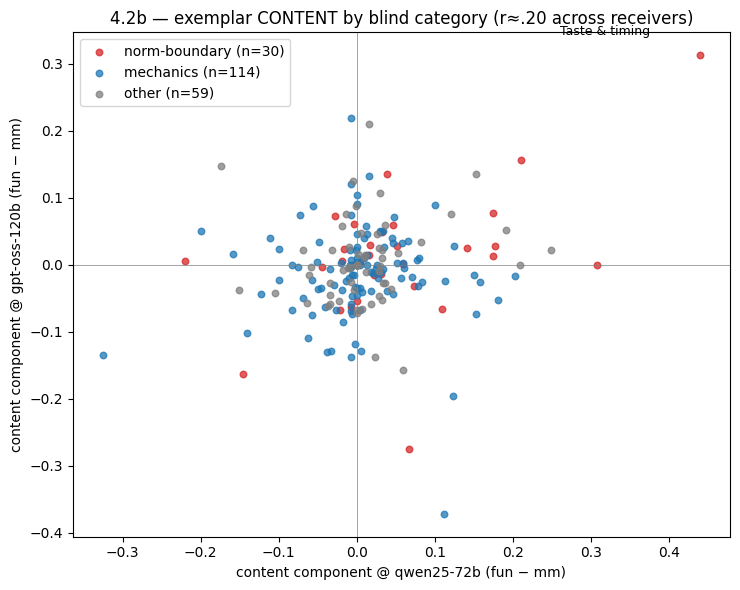

,content_qwen,content_gptoss
cat,,
mechanics,0.0000,-0.0049
norm-boundary,0.0320,0.0089
other,0.0018,0.0000


In [6]:
# (ii) cross-receiver content ledger + blind categories
led = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
cat = json.load(open(f"{D}/analyses/metric_categories_blind_v1.json"))
q = {r["b"]: r["functional"] - r["functionalmm"] for r in led["qwen25-72b"]}
g = {r["b"]: r["functional"] - r["functionalmm"] for r in led["gpt-oss-120b"]}
bases = sorted(set(q) & set(g) & set(cat))
colors = {"norm-boundary": "#d62728", "mechanics": "#1f77b4", "other": "#7f7f7f"}
fig, ax = plt.subplots(figsize=(7.5, 6))
for c in colors:
    xs = [q[b] for b in bases if cat[b] == c]; ys = [g[b] for b in bases if cat[b] == c]
    ax.scatter(xs, ys, s=22, alpha=.75, label=f"{c} (n={len(xs)})", color=colors[c])
tt = [b for b in bases if b.startswith("Taste and timing")]
for b in tt:
    ax.annotate("Taste & timing", (q[b], g[b]), fontsize=9, xytext=(q[b]-.18, g[b]+.03))
ax.axhline(0, color="gray", lw=.5); ax.axvline(0, color="gray", lw=.5)
ax.set_xlabel("content component @ qwen25-72b (fun − mm)")
ax.set_ylabel("content component @ gpt-oss-120b (fun − mm)")
ax.set_title("4.2b — exemplar CONTENT by blind category (r≈.20 across receivers)")
ax.legend(); plt.tight_layout(); plt.show()
dfc = pd.DataFrame({"base": bases, "cat": [cat[b] for b in bases],
                    "content_qwen": [q[b] for b in bases], "content_gptoss": [g[b] for b in bases]})
dfc.groupby("cat")[["content_qwen", "content_gptoss"]].median().round(4)

In [7]:
# frontier cells with CIs (both receivers) — canonical artifact
fr = json.load(open(f"{D}/analyses/frontier_limit_humor_v2.json"))
rows = []
for rcv, rr in fr["receivers"].items():
    for key, c in rr["contrasts"].items():
        cls, lbl = key.split("|")
        rows.append({"receiver": rcv, "class": cls, "contrast": lbl, "n": c["n"],
                     "delta": c["mean"], "ci_lo": c["ci"][0], "ci_hi": c["ci"][1]})
dffr = pd.DataFrame(rows)
dffr[dffr["class"].isin(["PLANTED", "ALL"])].sort_values(["receiver", "class", "contrast"])

,receiver,class,contrast,n,delta,ci_lo,ci_hi
27,glm-52,ALL,additive,14,0.0380,0.0086,0.0654
24,glm-52,ALL,ex-def,14,-0.0470,-0.1345,0.0280
26,glm-52,ALL,gate_authored,24,0.0650,-0.0040,0.1320
25,glm-52,ALL,gate_corpus,14,0.0717,0.0163,0.1361
18,glm-52,PLANTED,additive,5,0.0135,-0.0244,0.0470
15,glm-52,PLANTED,ex-def,5,-0.2098,-0.3277,-0.1139
17,glm-52,PLANTED,gate_authored,5,0.2015,0.0483,0.3487
16,glm-52,PLANTED,gate_corpus,5,0.1990,0.1303,0.2863
13,gpt-oss-120b,ALL,additive,14,0.0336,0.0010,0.0851
10,gpt-oss-120b,ALL,ex-def,14,-0.0291,-0.1066,0.0364


## 4.3 Scaling laws — what grows with receiver capability, and what doesn't

**Certified findings:**
- **Family staircases** (three families, crowd panels): recovery-vs-capability curves; the still-gaining-everywhere tail is **69/1032 constructs** (top−mid > .02 in all 3 families). The saturation census (corrected definition) puts ~35% of constructs still benefiting from capability at ladder-top in at least the family sense; family ownership ratios ≈ independence.
- **The shown channel over z** (flip-ladder, news-excluded): deficit at low z, parity-consistent only at top same-family rungs, positive point only on the selection-matched diagonal — a curve, not a point, that never robustly crosses.
- **Thinking as an entropy valve**: think-mode un-collapses small decoders (qwen3-1.7b: 53%→4% degenerate) with the effect vanishing up-ladder — the inversely capability-graded reasoning gain.
- **De-censoring**: the 69-construct tail is *not* de-censorable under the local-dialect reference (gpt-oss −.134\* vs the clean comparator, with healthy output variance) — the ceiling is a property of the construct–listener *pair*, which is the paper's closing claim. 5 individual ceiling-breaks stand as existence proofs.

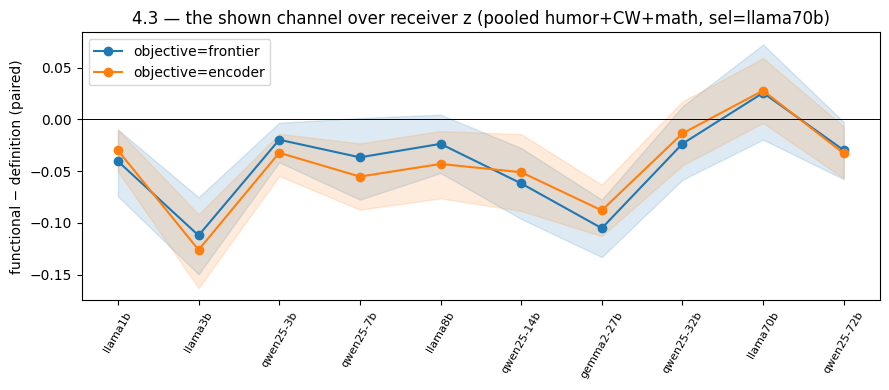

In [8]:
# flip-ladder delta curve (canonical: flipladder_curve_v2_nonews.json)
fl = json.load(open(f"{D}/analyses/flipladder_curve_v2_nonews.json"))
cells_ = [c for c in fl["cells"] if c.get("sel") == "llama70b" and "delta_mean" in c]
order = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
         "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
fig, ax = plt.subplots(figsize=(9, 4))
for obj, col in (("frontier", "#1f77b4"), ("encoder", "#ff7f0e")):
    sub = {c["ex"]: c for c in cells_ if c["obj"] == obj}
    xs = [i for i, ex in enumerate(order) if ex in sub]
    ys = [sub[order[i]]["delta_mean"] for i in xs]
    lo = [sub[order[i]]["ci"][0] for i in xs]; hi = [sub[order[i]]["ci"][1] for i in xs]
    ax.plot(xs, ys, marker="o", color=col, label=f"objective={obj}")
    ax.fill_between(xs, lo, hi, alpha=.15, color=col)
ax.axhline(0, color="k", lw=.7)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=60, fontsize=8)
ax.set_ylabel("functional − definition (paired)")
ax.set_title("4.3 — the shown channel over receiver z (pooled humor+CW+math, sel=llama70b)")
ax.legend(); plt.tight_layout(); plt.show()

constructs still gaining in ALL 3 families at ladder top: 69/1032


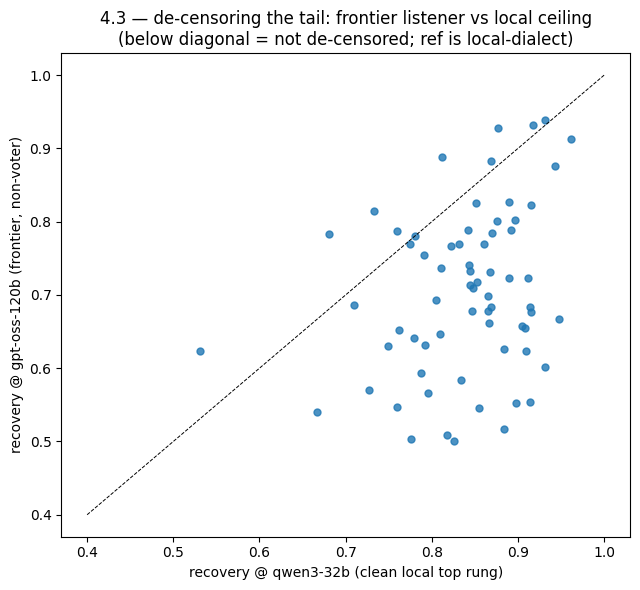

,task,b,gptoss,llama70b,qwen25-72b,qwen3-32b
6,humor,Human reference in comedy,0.939036,1.0,1.0,0.931170
0,humor,Affective distance and detachment conditions f...,0.931596,1.0,1.0,0.917738
8,humor,Incongruity and surprise mechanics,0.927144,1.0,1.0,0.876891
7,humor,Incongruity and juxtaposition techniques,0.912374,1.0,1.0,0.961212
60,math,"Prefer explicit constructive, sequential proof...",0.887617,1.0,1.0,0.811486
61,math,Self‑contained proof/solution,0.882779,1.0,1.0,0.869079
11,humor,"Surprise, misdirection, and dual‑read clarity",0.875782,1.0,1.0,0.943458
21,creative_writing,Ending strategy and effect,0.826235,1.0,1.0,0.889034


In [9]:
# family staircase summary + the deep-censored tail + de-censor outcome
fj = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))
rows = fj["full_rows"]
tm = pd.DataFrame([{"task": r["task"], "name": r["name"], **{f"top_minus_mid_{k}": v
                    for k, v in r["top_minus_mid"].items()}} for r in rows])
gaining = tm[(tm.filter(like="top_minus_mid") > .02).all(axis=1)]
print(f"constructs still gaining in ALL 3 families at ladder top: {len(gaining)}/{len(tm)}")
dec = json.load(open(f"{D}/analyses/decensor_harvest_v1.json"))
dd = pd.DataFrame(dec)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(dd["qwen3-32b"], dd["gptoss"], s=25, alpha=.8)
lims = [.4, 1.0]; ax.plot(lims, lims, "k--", lw=.7)
ax.set_xlabel("recovery @ qwen3-32b (clean local top rung)")
ax.set_ylabel("recovery @ gpt-oss-120b (frontier, non-voter)")
ax.set_title("4.3 — de-censoring the tail: frontier listener vs local ceiling\n(below diagonal = not de-censored; ref is local-dialect)")
plt.tight_layout(); plt.show()
dd.sort_values("gptoss", ascending=False).head(8)

---
### Canonical artifacts index (quote these, not notebook recomputations)
| claim | artifact |
|---|---|
| channel MI bounds / degeneracy | `analyses/mi_upper_census_v1.json`, `_v2.json` |
| flip-ladder curve | `analyses/flipladder_curve_v2_nonews.json` |
| cross-receiver content ledger | `analyses/v3sets_ledger_v1.json` + `metric_categories_blind_v1.json` |
| frontier limit cells (CIs, both receivers) | `analyses/frontier_limit_humor_v2.json` |
| GLM math corroboration | `analyses/glmexmath_harvest_v1.json` |
| de-censor verdict | `analyses/decensor_harvest_v1.json` + `flips/decensor_tail_v1.json` |
| family staircases / census | `analyses/family_verdict_join_v1.json`, `saturation_census_curve_v1.json` |

Full narrative + phrasing rules: `notes/2026-08-05__direction12-battery-plan.md`; Table-1 ledger: `notes/2026-07-19__gepa-consolidation-and-momega-upgrade-plan.md`.